### Generation of in-Silico Results

 - Particle Modeling -- Stokes model
 - Synthetic IFCB Sampling 
 

In [19]:
import numpy as np
import pandas as pd


def simulate_particle_settling(
    particle_classes,
    h = 0.110998,  # height of the syringe in meters
    n_particles=1000,
    fluid_density=1025,
    fluid_viscosity=1.05e-3,  # viscosity of seawater at 20°C in Pa·s
    g=9.81,
    dt=0.5,
    background_velocity_m_s=0.00009249833333, # flow rate of 1ml/240s
    seed=None,
):
    rng = np.random.default_rng(seed)

    classes = particle_classes.copy()
    classes["fraction"] = classes["fraction"] / classes["fraction"].sum()

    sampled = classes.sample(
        n=n_particles,
        replace=True,
        weights="fraction",
        random_state=seed,
    ).reset_index(drop=True)

    sampled["particle_id"] = np.arange(n_particles)

    sampled["initial_position_m"] = rng.uniform(0, h, n_particles)

    sampled["diameter_m"] = rng.normal(
        sampled["mean_diameter_m"],
        sampled["sd_diameter_m"],
    )

    sampled["density_kg_m3"] = rng.normal(
        sampled["mean_density_kg_m3"],
        sampled["sd_density_kg_m3"],
    )

    # Prevent impossible values
    sampled["diameter_m"] = sampled["diameter_m"].clip(lower=1e-6)
    sampled["density_kg_m3"] = sampled["density_kg_m3"].clip(
        lower=fluid_density + 1
    )

    radius_m = sampled["diameter_m"] / 2

    sampled["settling_velocity_m_s"] = (
        (2 / 9)
        * (sampled["density_kg_m3"] - fluid_density)
        * g
        * radius_m**2
        / fluid_viscosity
    )

    sampled["background_velocity_m_s"] = background_velocity_m_s

    sampled["net_velocity_m_s"] = (
        sampled["settling_velocity_m_s"]
        + sampled["background_velocity_m_s"]
    )

    sampled["time_to_bottom_s"] = np.where(
        sampled["net_velocity_m_s"] > 0,
        sampled["initial_position_m"] / sampled["net_velocity_m_s"],
        np.inf,
    )

    sampled["arrival_timestep"] = np.where(
        np.isfinite(sampled["time_to_bottom_s"]),
        np.ceil(sampled["time_to_bottom_s"] / dt).astype(int),
        -1,
    )

    results = sampled[
        [
            "particle_id",
            "size_class",
            "diameter_m",
            "density_kg_m3",
            "initial_position_m",
            "settling_velocity_m_s",
            "background_velocity_m_s",
            "net_velocity_m_s",
            "time_to_bottom_s",
            "arrival_timestep",
        ]
    ]

    return results



#### This could be made more sophisticated but not sure how to go about this and if the level of detail is needed

In [20]:

# -------------------------
# Example particle classes
# -------------------------

particle_classes = pd.DataFrame({
    "size_class": [
        "cryptophyte",
        "dinoflagellate",
        "shellfish_larva",
    ],

    "mean_diameter_m": [
        10e-6,
        50e-6,
        100e-6,
    ],

    "sd_diameter_m": [
        3e-6,
        15e-6,
        25e-6,
    ],

    "mean_density_kg_m3": [
        1050,
        1100,
        1200,
    ],

    "sd_density_kg_m3": [
        10,
        25,
        50,
    ],

    "fraction": [
        0.4,
        0.4,
        0.2,
    ],
})


# -------------------------
# Run simulation
# -------------------------

df = simulate_particle_settling(
    particle_classes=particle_classes,
    n_particles=25000,
    fluid_density=1025,        # seawater density, kg/m^3
    fluid_viscosity=1.05e-3,     # water viscosity, Pa*s
    dt=0.5,                     # timestep, s
    background_velocity_m_s=0.00009249833333, # flow rate of 1ml/240s,
    seed=42,
)


print(df.head())
print(df.groupby("size_class")["time_to_bottom_s"].describe())


   particle_id       size_class  diameter_m  density_kg_m3  \
0            0      cryptophyte    0.000007    1026.000000   
1            1  shellfish_larva    0.000085    1214.037640   
2            2   dinoflagellate    0.000058    1081.318984   
3            3   dinoflagellate    0.000050    1099.415764   
4            4      cryptophyte    0.000009    1058.321851   

   initial_position_m  settling_velocity_m_s  background_velocity_m_s  \
0            0.085908           2.497590e-08                 0.000092   
1            0.048715           7.072329e-04                 0.000092   
2            0.095303           9.836785e-05                 0.000092   
3            0.077406           9.518724e-05                 0.000092   
4            0.010453           1.269799e-06                 0.000092   

   net_velocity_m_s  time_to_bottom_s  arrival_timestep  
0          0.000093        928.496551              1857  
1          0.000800         60.913750               122  
2          0.0

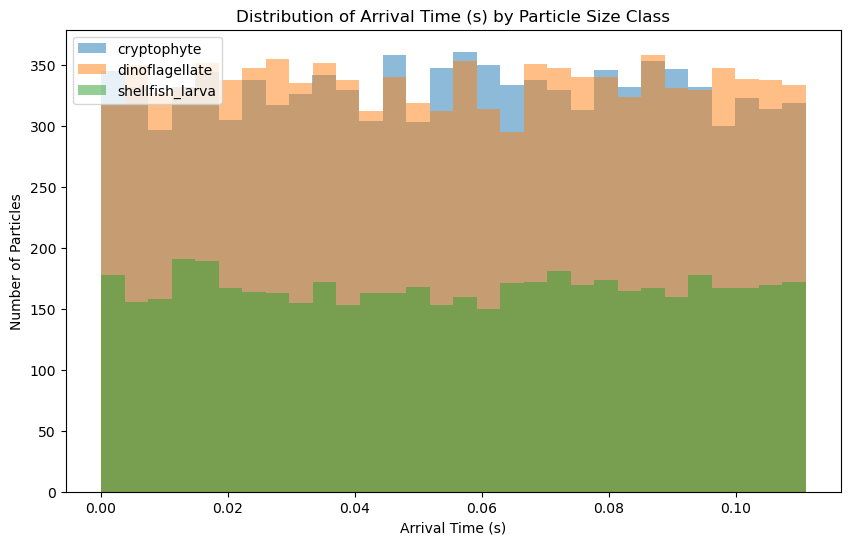

In [36]:
plt.figure(figsize=(10, 6))
for size_class in particle_classes["size_class"]:
    subset = df[df["size_class"] == size_class]
    plt.hist(subset["initial_position_m"], bins=30, alpha=0.5, label=size_class)  # Limit x-axis for better visualization
plt.xlabel("Arrival Time (s)")
plt.ylabel("Number of Particles")
plt.title("Distribution of Arrival Time (s) by Particle Size Class")
plt.legend()
plt.show()

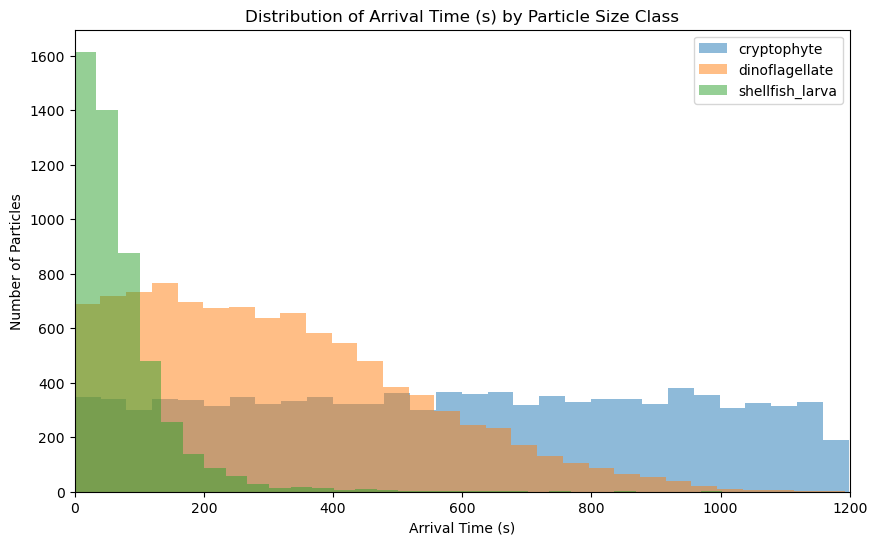

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for size_class in particle_classes["size_class"]:
    subset = df[df["size_class"] == size_class]
    plt.hist(subset["time_to_bottom_s"], bins=30, alpha=0.5, label=size_class)
plt.xlim(0, 1200)  # Limit x-axis for better visualization
plt.xlabel("Arrival Time (s)")
plt.ylabel("Number of Particles")
plt.title("Distribution of Arrival Time (s) by Particle Size Class")
plt.legend()
plt.show()

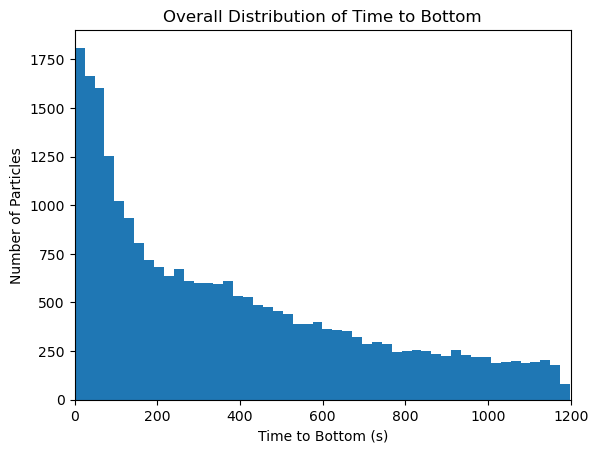

In [ ]:
plt.hist(df["time_to_bottom_s"], bins=50)
plt.xlabel("Arrival Time (s)")
plt.ylabel("Number of Particles")
plt.title("Overall Distribution of Arrival Time")
plt.xlim(0, 1200)  # Limit x-axis for better visualization
plt.show()

In [6]:
import numpy as np
import pandas as pd

def simulate_ifcb_sampling_df(input_df, arrival_times_col, inhibit_time=0.08):
    """
    Simulate IFCB sampling with a fixed inhibit time after each accepted trigger.

    Parameters
    ----------
    input_df : pandas.DataFrame
        DataFrame containing the particle arrival times.
    arrival_times_col : str
        Name of the column in df that contains the particle arrival times.
        Must be numeric in order of arrival
    inhibit_time : float
        Time after each accepted trigger during which new particles cannot be sampled.

    Returns
    -------
    sampled_df : pandas.DataFrame
        DataFrame containing accepted particle arrival times.
    rejected_df : pandas.DataFrame
        DataFrame containing rejected particle arrival times.
    """
    arrival_times = np.asarray(input_df[arrival_times_col])

    sampled_flags = []
    next_available_time = 0
    total_inhibit = 0
    cumulative_inhibit = []

    for t in arrival_times:
        if t >= next_available_time:
            sampled_flags.append(True)
            next_available_time = t + inhibit_time
            total_inhibit = total_inhibit + inhibit_time
            cumulative_inhibit.append(total_inhibit)
        else:
            sampled_flags.append(False)
            cumulative_inhibit.append(total_inhibit)

    df = input_df.copy()

    df["sampled"] = sampled_flags
    df["cumulative_inhibit"] = cumulative_inhibit


    return df

In [14]:
ordered_df = df.sort_values(by="time_to_bottom_s").reset_index(drop=True)
ordered_df.head(10)

,particle_id,size_class,diameter_m,density_kg_m3,initial_position_m,settling_velocity_m_s,background_velocity_m_s,net_velocity_m_s,time_to_bottom_s,arrival_timestep
0,12490,shellfish_larva,0.000151,1187.061588,0.000014,1.929989e-03,0.000092,0.002022,0.006855,1
1,23537,shellfish_larva,0.000103,1282.263835,0.000021,1.405155e-03,0.000092,0.001498,0.014056,1
2,10217,cryptophyte,0.000008,1049.610135,0.000001,7.598213e-07,0.000092,0.000093,0.015674,1
3,18983,cryptophyte,0.000014,1060.585988,0.000002,3.795434e-06,0.000092,0.000096,0.022177,1
4,1157,shellfish_larva,0.000123,1207.273439,0.000058,1.436044e-03,0.000092,0.001529,0.037670,1
5,13201,dinoflagellate,0.000088,1133.267229,0.000022,4.391157e-04,0.000092,0.000532,0.041301,1
6,20602,shellfish_larva,0.000099,1286.868750,0.000078,1.336446e-03,0.000092,0.001429,0.054668,1
7,21776,shellfish_larva,0.000125,1141.586307,0.000062,9.384760e-04,0.000092,0.001031,0.060060,1
8,16209,cryptophyte,0.000009,1034.978953,0.000006,4.038205e-07,0.000092,0.000093,0.060488,1
9,18035,shellfish_larva,0.000098,1166.566615,0.000062,6.997778e-04,0.000092,0.000792,0.077639,1


In [15]:
ifcb_sampled_df = simulate_ifcb_sampling_df(ordered_df, "time_to_bottom_s", inhibit_time=0.08)

In [16]:
ifcb_sampled_df.head()

,particle_id,size_class,diameter_m,density_kg_m3,initial_position_m,settling_velocity_m_s,background_velocity_m_s,net_velocity_m_s,time_to_bottom_s,arrival_timestep,sampled,cumulative_inhibit
0,12490,shellfish_larva,0.000151,1187.061588,0.000014,1.929989e-03,0.000092,0.002022,0.006855,1,True,0.08
1,23537,shellfish_larva,0.000103,1282.263835,0.000021,1.405155e-03,0.000092,0.001498,0.014056,1,False,0.08
2,10217,cryptophyte,0.000008,1049.610135,0.000001,7.598213e-07,0.000092,0.000093,0.015674,1,False,0.08
3,18983,cryptophyte,0.000014,1060.585988,0.000002,3.795434e-06,0.000092,0.000096,0.022177,1,False,0.08
4,1157,shellfish_larva,0.000123,1207.273439,0.000058,1.436044e-03,0.000092,0.001529,0.037670,1,False,0.08


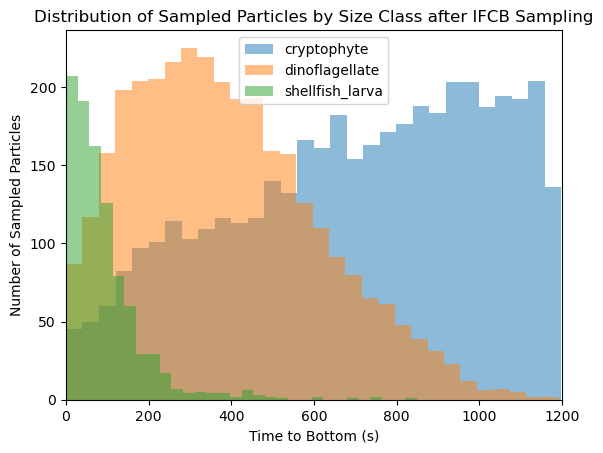

In [ ]:
sampled_df = ifcb_sampled_df[ifcb_sampled_df["sampled"] == True]
for size_class in particle_classes["size_class"]:
    subset = sampled_df[sampled_df["size_class"] == size_class]
    plt.hist(subset["time_to_bottom_s"], bins=30, alpha=0.5, label=size_class)
plt.xlim(0, 1200)  # Limit x-axis for better visualization
plt.xlabel("Arrival Time (s)")
plt.ylabel("Number of Sampled Particles")
plt.title("Distribution of Sampled Particles by Size Class after IFCB Sampling")
plt.legend()
plt.show()

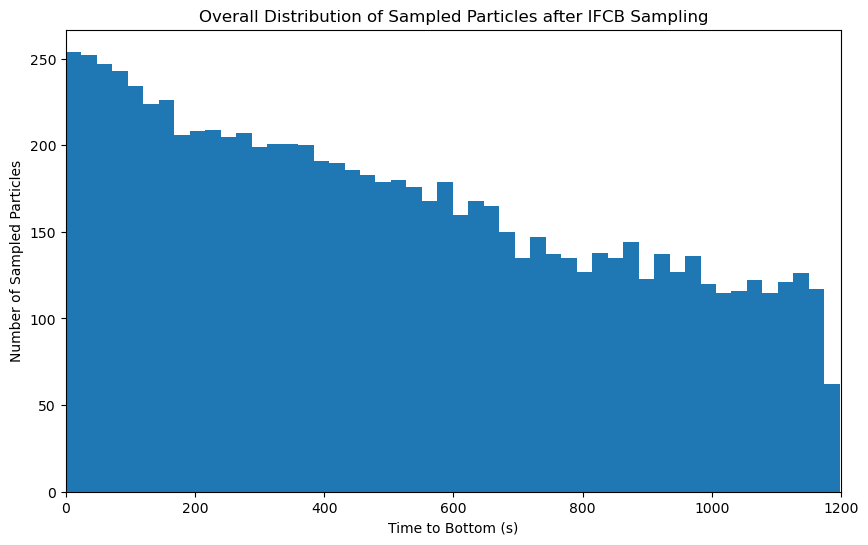

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(sampled_df["time_to_bottom_s"], bins=50)
plt.xlabel("Arrival Time (s)")
plt.ylabel("Number of Sampled Particles")
plt.title("Overall Distribution of Sampled Particles after IFCB Sampling")
plt.xlim(0, 1200)  # Limit x-axis for better visualization
plt.show()

In [22]:
### Calculate ifcb sampled concentration vs real concentration

ifcb_sampled_df.head()

,particle_id,size_class,diameter_m,density_kg_m3,initial_position_m,settling_velocity_m_s,background_velocity_m_s,net_velocity_m_s,time_to_bottom_s,arrival_timestep,sampled,cumulative_inhibit
0,12490,shellfish_larva,0.000151,1187.061588,0.000014,1.929989e-03,0.000092,0.002022,0.006855,1,True,0.08
1,23537,shellfish_larva,0.000103,1282.263835,0.000021,1.405155e-03,0.000092,0.001498,0.014056,1,False,0.08
2,10217,cryptophyte,0.000008,1049.610135,0.000001,7.598213e-07,0.000092,0.000093,0.015674,1,False,0.08
3,18983,cryptophyte,0.000014,1060.585988,0.000002,3.795434e-06,0.000092,0.000096,0.022177,1,False,0.08
4,1157,shellfish_larva,0.000123,1207.273439,0.000058,1.436044e-03,0.000092,0.001529,0.037670,1,False,0.08


In [24]:
## Real concentration calculation
real_concs = []
size_classes = particle_classes["size_class"].unique()

for size_class in size_classes:
    subset = df[df["size_class"] == size_class]
    real_conc = len(subset) / 5  # Assuming 1 ml sample volume
    real_concs.append(real_conc)

print(real_concs)

[1982.6, 2014.0, 1003.4]


In [26]:
## IFCB sampled concentration calculation
ifcb_sampled_concs = []
volume_analyzed = (ifcb_sampled_df["time_to_bottom_s"].max() - ifcb_sampled_df["cumulative_inhibit"].max())/240
for size_class in size_classes:
    subset = sampled_df[sampled_df["size_class"] == size_class]
    ifcb_sampled_conc = len(subset) / volume_analyzed  # Assuming 1 ml sample volume
    ifcb_sampled_concs.append(ifcb_sampled_conc)
print(ifcb_sampled_concs)

[np.float64(1941.629368660366), np.float64(1483.80589102293), np.float64(432.18536288973957)]


In [29]:
concs_df = pd.DataFrame({
    "size_class": size_classes,
    "real_concentration": real_concs,
    "ifcb_sampled_concentration": ifcb_sampled_concs,
})

concs_df["Bias"] = (concs_df["ifcb_sampled_concentration"] - concs_df["real_concentration"]) / concs_df["real_concentration"] * 100

concs_df.head()

,size_class,real_concentration,ifcb_sampled_concentration,Bias
0,cryptophyte,1982.6,1941.629369,-2.066510
1,dinoflagellate,2014.0,1483.805891,-26.325427
2,shellfish_larva,1003.4,432.185363,-56.927909


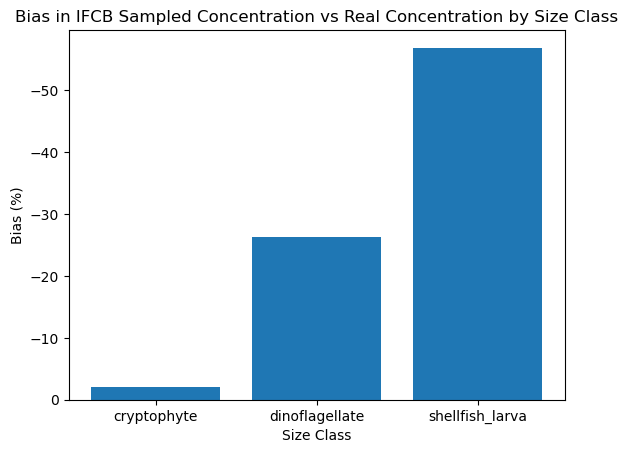

In [33]:
plt.bar(concs_df["size_class"], concs_df["Bias"])
plt.xlabel("Size Class")
plt.ylabel("Bias (%)")
plt.title("Bias in IFCB Sampled Concentration vs Real Concentration by Size Class")
plt.gca().invert_yaxis()